 MOBILE ROBOT OBSTACLE AVOIDANCE USING SUPPORT VECTOR MACHINE (SVM)

📍 Enter Starting Point:
   X coordinate: 1
   Y coordinate: 2

🎯 Enter Goal Point:
   X coordinate: 3
   Y coordinate: 2

🚧 Enter Number of Obstacles:
   n = 2

⭕ Enter Obstacle 1:
   X coordinate: 1
   Y coordinate: 2
   Radius: 0.1

⭕ Enter Obstacle 2:
   X coordinate: 2
   Y coordinate: 1
   Radius: 0.1

STARTING SVM-BASED PATH PLANNING...

🤖 Training SVM Model...
✓ SVM Model Trained Successfully!
✓ Training Accuracy: 99.23%

🗺️  Finding Path using SVM...

RESULTS:
✓ Path found with 3 waypoints
✓ Total path length: 3.20 units
✓ Straight line distance: 2.00 units
✓ Path efficiency: 62.49%

📋 Path Waypoints:
   Waypoint 0: (1.00, 2.00)
   Waypoint 1: (1.04, 3.00)
   Waypoint 2: (3.00, 2.00)

📊 Generating Visualization...
✓ Visualization saved as 'path_planning_svm.png'


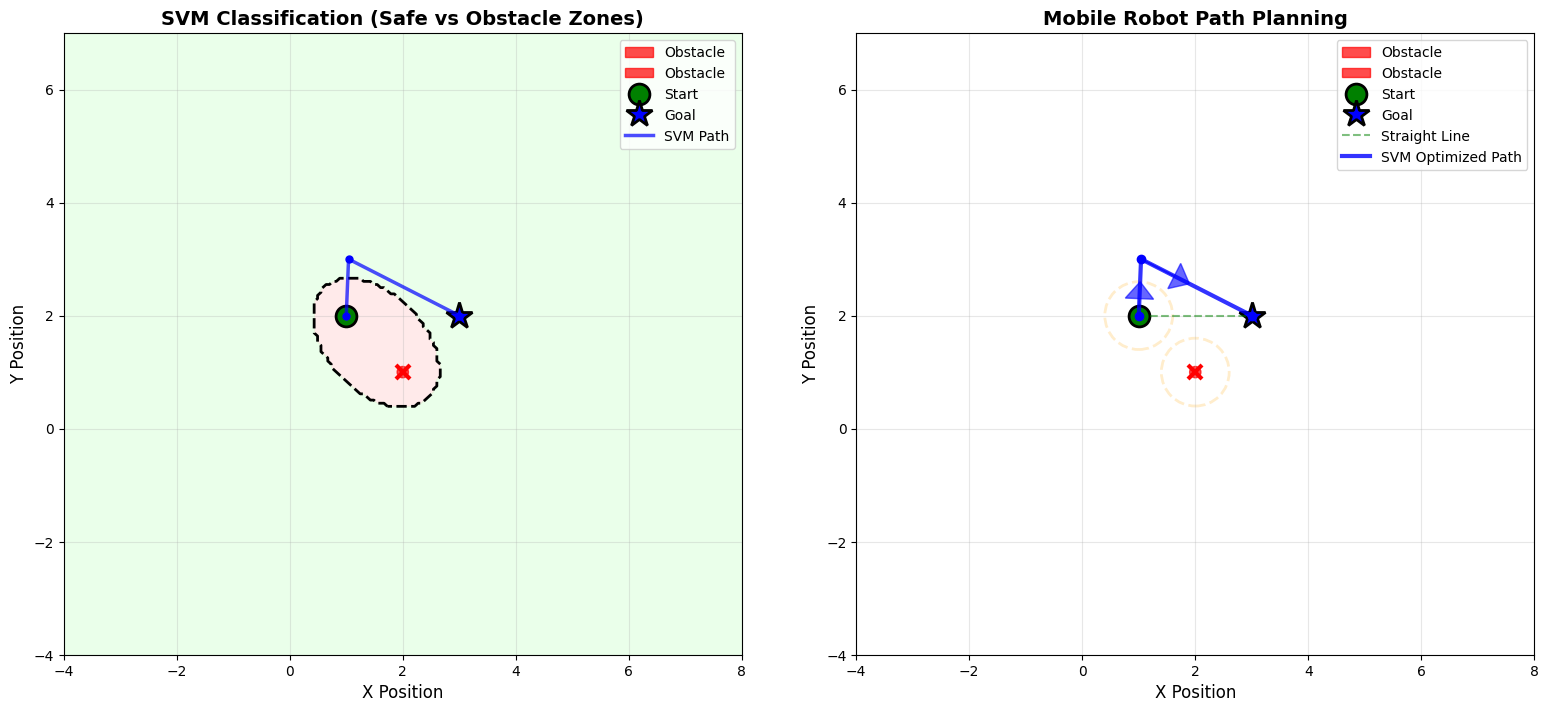


✅ Program completed successfully!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


class ObstacleAvoidanceSVM:
    def __init__(self, start, goal, obstacles):
        """
        Initialize the obstacle avoidance system

        Parameters:
        start: tuple (x, y) - starting point
        goal: tuple (x, y) - goal point
        obstacles: list of tuples [(x, y, radius), ...] - obstacle positions and radii
        """
        self.start = np.array(start)
        self.goal = np.array(goal)
        self.obstacles = obstacles
        self.svm_model = None
        self.scaler = StandardScaler()

    def generate_training_data(self):
        """
        Generate training data for SVM
        Label: 1 = Safe zone, -1 = Obstacle zone
        """
        # Define the workspace boundaries
        all_x = [self.start[0], self.goal[0]] + [obs[0] for obs in self.obstacles]
        all_y = [self.start[1], self.goal[1]] + [obs[1] for obs in self.obstacles]

        x_min, x_max = min(all_x) - 5, max(all_x) + 5
        y_min, y_max = min(all_y) - 5, max(all_y) + 5

        # Generate grid points
        X_train = []
        y_train = []

        # Generate points in safe zones
        for _ in range(2000):
            x = np.random.uniform(x_min, x_max)
            y = np.random.uniform(y_min, y_max)

            # Check if point is inside any obstacle
            is_safe = True
            for obs_x, obs_y, obs_radius in self.obstacles:
                distance = np.sqrt((x - obs_x)**2 + (y - obs_y)**2)
                if distance <= obs_radius + 0.5:  # Add safety margin
                    is_safe = False
                    break

            X_train.append([x, y])
            y_train.append(1 if is_safe else -1)

        # Generate points specifically in obstacle zones
        for obs_x, obs_y, obs_radius in self.obstacles:
            for _ in range(300):
                # Generate points around obstacle
                angle = np.random.uniform(0, 2 * np.pi)
                r = np.random.uniform(0, obs_radius)
                x = obs_x + r * np.cos(angle)
                y = obs_y + r * np.sin(angle)
                X_train.append([x, y])
                y_train.append(-1)

        return np.array(X_train), np.array(y_train)

    def train_svm(self):
        """
        Train SVM classifier to distinguish between safe and obstacle zones
        """
        print("\n🤖 Training SVM Model...")
        X_train, y_train = self.generate_training_data()

        # Normalize features
        X_train_scaled = self.scaler.fit_transform(X_train)

        # Train SVM with RBF kernel for non-linear decision boundary
        self.svm_model = svm.SVC(kernel='rbf', gamma='auto', C=10.0)
        self.svm_model.fit(X_train_scaled, y_train)

        # Calculate accuracy
        accuracy = self.svm_model.score(X_train_scaled, y_train)
        print(f"✓ SVM Model Trained Successfully!")
        print(f"✓ Training Accuracy: {accuracy * 100:.2f}%")

    def is_point_safe(self, point):
        """
        Check if a point is in safe zone using trained SVM
        """
        point_scaled = self.scaler.transform([point])
        prediction = self.svm_model.predict(point_scaled)
        return prediction[0] == 1

    def find_path(self, num_waypoints=50):
        """
        Find path from start to goal using SVM classification
        """
        print("\n🗺️  Finding Path using SVM...")

        # Generate candidate waypoints along the straight line
        t = np.linspace(0, 1, num_waypoints)
        straight_path = np.outer(1-t, self.start) + np.outer(t, self.goal)

        # Refine path to avoid obstacles
        refined_path = [self.start]

        for i in range(1, len(straight_path) - 1):
            point = straight_path[i]

            if not self.is_point_safe(point):
                # Point is in obstacle - find detour
                # Try points perpendicular to the line
                direction = self.goal - self.start
                perpendicular = np.array([-direction[1], direction[0]])
                perpendicular = perpendicular / np.linalg.norm(perpendicular)

                # Search for safe point
                found_safe = False
                for offset in [1, 2, 3, 4, 5]:
                    for sign in [1, -1]:
                        candidate = point + sign * offset * perpendicular
                        if self.is_point_safe(candidate):
                            refined_path.append(candidate)
                            found_safe = True
                            break
                    if found_safe:
                        break

                if not found_safe:
                    # If no perpendicular point found, skip this waypoint
                    continue
            else:
                refined_path.append(point)

        refined_path.append(self.goal)

        # Smooth the path - remove unnecessary waypoints
        smoothed_path = [refined_path[0]]
        i = 0
        while i < len(refined_path) - 1:
            j = len(refined_path) - 1
            while j > i + 1:
                # Check if we can go directly from i to j
                can_connect = True
                intermediate_points = np.linspace(refined_path[i], refined_path[j], 20)
                for pt in intermediate_points:
                    if not self.is_point_safe(pt):
                        can_connect = False
                        break

                if can_connect:
                    smoothed_path.append(refined_path[j])
                    i = j
                    break
                j -= 1
            else:
                i += 1
                if i < len(refined_path):
                    smoothed_path.append(refined_path[i])

        return np.array(smoothed_path)

    def calculate_path_length(self, path):
        """
        Calculate total path length
        """
        length = 0
        for i in range(len(path) - 1):
            length += np.linalg.norm(path[i+1] - path[i])
        return length

    def visualize(self, path):
        """
        Visualize the environment, SVM decision boundary, and path
        """
        print("\n📊 Generating Visualization...")

        # Create figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        # Define plot boundaries
        all_x = [self.start[0], self.goal[0]] + [obs[0] for obs in self.obstacles]
        all_y = [self.start[1], self.goal[1]] + [obs[1] for obs in self.obstacles]
        x_min, x_max = min(all_x) - 5, max(all_x) + 5
        y_min, y_max = min(all_y) - 5, max(all_y) + 5

        # Plot 1: SVM Decision Boundary
        ax1.set_title('SVM Classification (Safe vs Obstacle Zones)', fontsize=14, fontweight='bold')

        # Create mesh grid
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))

        # Predict for each point in mesh
        Z = self.svm_model.predict(self.scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
        Z = Z.reshape(xx.shape)

        # Plot decision boundary
        ax1.contourf(xx, yy, Z, alpha=0.4, levels=[-1, 0, 1], colors=['#ffcccc', '#ccffcc'])
        ax1.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2, linestyles='dashed')

        # Plot obstacles
        for obs_x, obs_y, obs_radius in self.obstacles:
            circle = plt.Circle((obs_x, obs_y), obs_radius, color='red', alpha=0.7, label='Obstacle')
            ax1.add_patch(circle)
            ax1.plot(obs_x, obs_y, 'rx', markersize=10, markeredgewidth=3)

        # Plot start and goal
        ax1.plot(self.start[0], self.start[1], 'go', markersize=15, label='Start', markeredgewidth=2, markeredgecolor='black')
        ax1.plot(self.goal[0], self.goal[1], 'b*', markersize=20, label='Goal', markeredgewidth=2, markeredgecolor='black')

        # Plot path
        if len(path) > 0:
            ax1.plot(path[:, 0], path[:, 1], 'b-', linewidth=2.5, alpha=0.7, label='SVM Path')
            ax1.plot(path[:, 0], path[:, 1], 'bo', markersize=5)

        ax1.set_xlabel('X Position', fontsize=12)
        ax1.set_ylabel('Y Position', fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='best')
        ax1.set_xlim(x_min, x_max)
        ax1.set_ylim(y_min, y_max)
        ax1.set_aspect('equal')

        # Plot 2: Path Planning Result
        ax2.set_title('Mobile Robot Path Planning', fontsize=14, fontweight='bold')

        # Plot obstacles
        for obs_x, obs_y, obs_radius in self.obstacles:
            circle = plt.Circle((obs_x, obs_y), obs_radius, color='red', alpha=0.7, label='Obstacle')
            ax2.add_patch(circle)
            ax2.plot(obs_x, obs_y, 'rx', markersize=10, markeredgewidth=3)
            # Add safety margin visualization
            circle_margin = plt.Circle((obs_x, obs_y), obs_radius + 0.5, color='orange', alpha=0.2, linestyle='--', fill=False, linewidth=2)
            ax2.add_patch(circle_margin)

        # Plot start and goal
        ax2.plot(self.start[0], self.start[1], 'go', markersize=15, label='Start', markeredgewidth=2, markeredgecolor='black')
        ax2.plot(self.goal[0], self.goal[1], 'b*', markersize=20, label='Goal', markeredgewidth=2, markeredgecolor='black')

        # Plot straight line (desired path)
        ax2.plot([self.start[0], self.goal[0]], [self.start[1], self.goal[1]], 'g--',
                linewidth=1.5, alpha=0.5, label='Straight Line')

        # Plot SVM-based path
        if len(path) > 0:
            ax2.plot(path[:, 0], path[:, 1], 'b-', linewidth=3, alpha=0.8, label='SVM Optimized Path')
            ax2.plot(path[:, 0], path[:, 1], 'bo', markersize=6)

            # Add arrows to show direction
            for i in range(0, len(path)-1, max(1, len(path)//10)):
                dx = path[i+1, 0] - path[i, 0]
                dy = path[i+1, 1] - path[i, 1]
                ax2.arrow(path[i, 0], path[i, 1], dx*0.3, dy*0.3,
                         head_width=0.5, head_length=0.3, fc='blue', ec='blue', alpha=0.6)

        ax2.set_xlabel('X Position', fontsize=12)
        ax2.set_ylabel('Y Position', fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='best')
        ax2.set_xlim(x_min, x_max)
        ax2.set_ylim(y_min, y_max)
        ax2.set_aspect('equal')

        plt.tight_layout()
        plt.savefig('path_planning_svm.png', dpi=300, bbox_inches='tight')
        print("✓ Visualization saved as 'path_planning_svm.png'")
        plt.show()


def main():
    """
    Main function to run the obstacle avoidance program
    """
    print("="*70)
    print(" MOBILE ROBOT OBSTACLE AVOIDANCE USING SUPPORT VECTOR MACHINE (SVM)")
    print("="*70)

    # Get starting point from user
    print("\n📍 Enter Starting Point:")
    start_x = float(input("   X coordinate: "))
    start_y = float(input("   Y coordinate: "))
    start = (start_x, start_y)

    # Get goal point from user
    print("\n🎯 Enter Goal Point:")
    goal_x = float(input("   X coordinate: "))
    goal_y = float(input("   Y coordinate: "))
    goal = (goal_x, goal_y)

    # Get number of obstacles
    print("\n🚧 Enter Number of Obstacles:")
    n = int(input("   n = "))

    # Get obstacle information
    obstacles = []
    for i in range(n):
        print(f"\n⭕ Enter Obstacle {i+1}:")
        obs_x = float(input(f"   X coordinate: "))
        obs_y = float(input(f"   Y coordinate: "))
        obs_radius = float(input(f"   Radius: "))
        obstacles.append((obs_x, obs_y, obs_radius))

    print("\n" + "="*70)
    print("STARTING SVM-BASED PATH PLANNING...")
    print("="*70)

    # Create obstacle avoidance system
    oa_system = ObstacleAvoidanceSVM(start, goal, obstacles)

    # Train SVM
    oa_system.train_svm()

    # Find path
    path = oa_system.find_path(num_waypoints=50)

    # Calculate path metrics
    path_length = oa_system.calculate_path_length(path)
    straight_line_distance = np.linalg.norm(np.array(goal) - np.array(start))

    print("\n" + "="*70)
    print("RESULTS:")
    print("="*70)
    print(f"✓ Path found with {len(path)} waypoints")
    print(f"✓ Total path length: {path_length:.2f} units")
    print(f"✓ Straight line distance: {straight_line_distance:.2f} units")
    print(f"✓ Path efficiency: {(straight_line_distance/path_length)*100:.2f}%")
    print("="*70)

    # Print waypoints
    print("\n📋 Path Waypoints:")
    for i, waypoint in enumerate(path):
        print(f"   Waypoint {i}: ({waypoint[0]:.2f}, {waypoint[1]:.2f})")

    # Visualize
    oa_system.visualize(path)

    print("\n✅ Program completed successfully!")


if __name__ == "__main__":
    main()